## RBF-PU Spectral Method

In [78]:
import numpy as np
from rbf.pde.nodes import poisson_disc_nodes
from PuHelper import *
import matplotlib.pyplot as plt
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [79]:
#Params
epsilon = 2
delta = 0.01
nodes_in_patch= 200
overlap = 3

In [80]:
vert = np.array([[0, 0], [1, 0], [1, 1], [0, 1]])
edges = np.array([[0, 1], [1, 2], [2, 3], [3, 0]])
nodes, groups, _ = poisson_disc_nodes(delta, (vert, edges))

In [81]:
interior_nodes = nodes[groups['interior']]
boundary_nodes = nodes[groups['boundary:all']]

nodes = np.vstack((interior_nodes, boundary_nodes))
min_boundary_idx = len(interior_nodes)


In [82]:
centers = GenCenters(nodes, nodes_in_patch, overlap)
patches, radii, node_to_patch = GenPatches(nodes, centers, nodes_in_patch)

phis = GenLocalPhi(nodes, patches, epsilon)
grads = GenLocalGrads(nodes, patches, phis, epsilon)
laps = GenLocalLaps(nodes, patches, phis, epsilon)

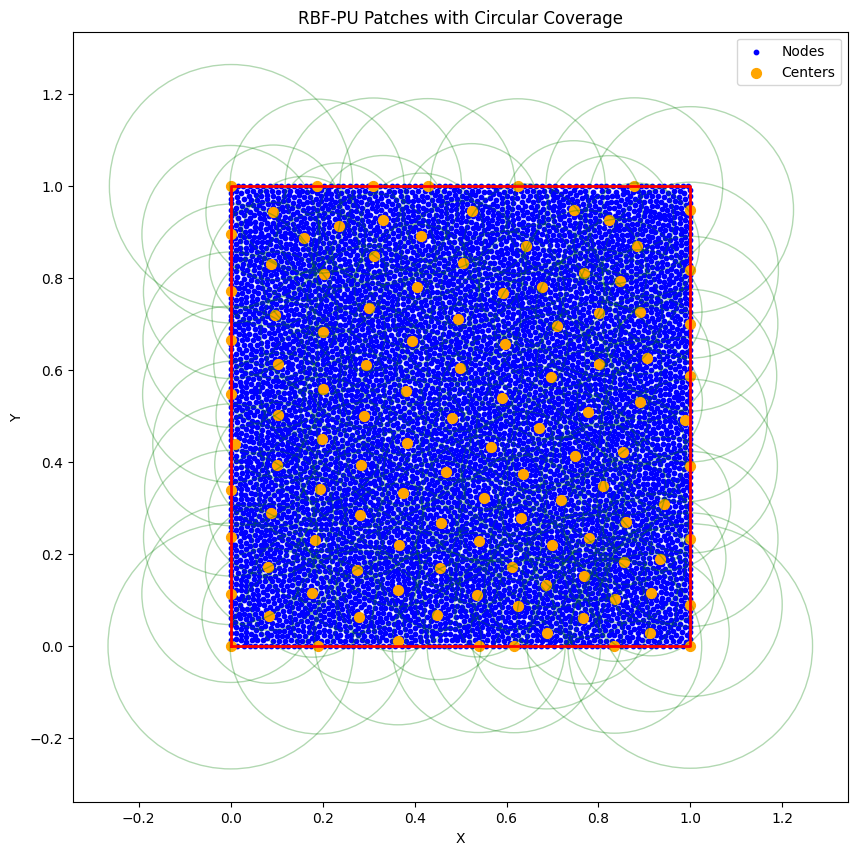

Max patch radius: 0.2674
Min patch radius: 0.1337
Mean patch radius: 0.1528


In [83]:
# Plot the circular patches
plt.figure(figsize=(10, 10))
plt.scatter(nodes[:, 0], nodes[:, 1], s=10, c='blue', label='Nodes')
plt.scatter(np.array(centers)[:, 0], np.array(centers)[:, 1], s=50, c='orange', label='Centers')

# Draw circles for each patch
for center, radius in zip(centers, radii):
    circle = plt.Circle(center, radius, fill=False, edgecolor='green', alpha=0.3)
    plt.gca().add_patch(circle)

plt.plot(vert[[0, 1, 2, 3, 0], 0], vert[[0, 1, 2, 3, 0], 1], 'r-', linewidth=2)
plt.axis('equal')
plt.title('RBF-PU Patches with Circular Coverage')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

print(f"Max patch radius: {np.max(radii):.4f}")
print(f"Min patch radius: {np.min(radii):.4f}")
print(f"Mean patch radius: {np.mean(radii):.4f}")


In [84]:
u1 = np.ones(len(nodes))

Lapu = ApplyLap(u1, nodes, patches, centers, radii, grads, laps)

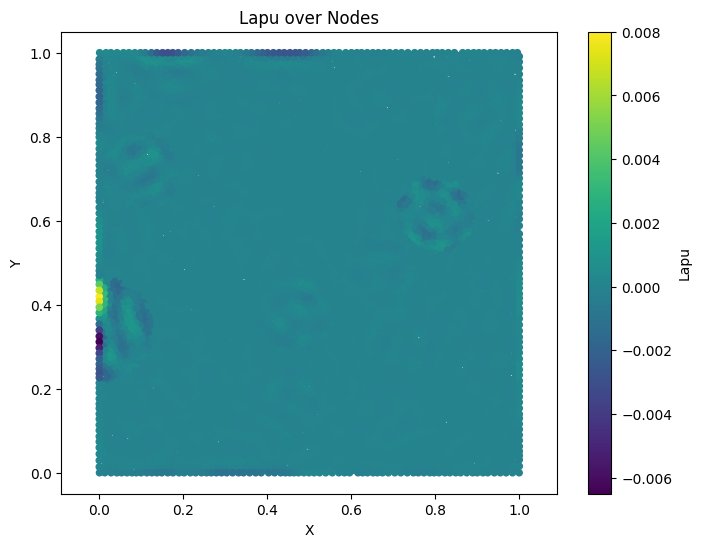

In [85]:
plt.figure(figsize=(8, 6))
plt.scatter(nodes[:, 0], nodes[:, 1], c=Lapu, s=20, cmap="viridis")
plt.colorbar(label="Lapu")
plt.axis("equal")
plt.title("Lapu over Nodes")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

In [86]:
np.max(Lapu), np.min(Lapu), np.mean(Lapu)

(np.float64(0.008001127092708081),
 np.float64(-0.006503695674389),
 np.float64(-1.3712693147307508e-05))